# Market Basket Analysis — Apriori vs FP-Growth vs ECLAT
**Retail Intelligence Platform | Data Mining Project — Phase 2**

**Team:** Mohamed Goma, Abdullah Yasser, Mohamed Khaled, Mohamed Saleh, Mahitab Ayman  
**Course:** Data Mining | **Instructor:** Dr. Shaimaa Mohamed  
**Dataset:** Dunnhumby Complete Journey


## Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted")


Mounted at /content/drive
✅ Drive mounted


## Step 2 — Install Libraries

In [2]:
import sys
!{sys.executable} -m pip install mlxtend --quiet
print("✅ Libraries ready")


✅ Libraries ready


## Step 3 — Imports

In [3]:
import time
import tracemalloc
import warnings
import itertools
import math
import gc
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 60)
print("✅ All imports done")


✅ All imports done


## Step 4 — Configuration
> ⚠️ Only change `CSV_PATH` to match where your file is in Drive.


In [4]:
# ── ONLY CHANGE THIS PATH ────────────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/preprocessed/basket_items_for_mba.csv"

# ── Algorithm settings (do not change) ───────────────────────────────────────
MIN_SUPPORTS    = [0.001, 0.003, 0.005, 0.01]
MIN_CONFIDENCES = [0.3, 0.4, 0.5, 0.6]
MAX_ITEMSET_SIZE = 3
ALGORITHMS       = ["Apriori", "FP-Growth", "ECLAT"]

# ── Output folder ─────────────────────────────────────────────────────────────
OUTPUT_DIR = Path("/content/outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"CSV path     : {CSV_PATH}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"Algorithms   : {ALGORITHMS}")
print(f"Supports     : {MIN_SUPPORTS}")
print(f"Confidences  : {MIN_CONFIDENCES}")


CSV path     : /content/drive/MyDrive/preprocessed/basket_items_for_mba.csv
Output folder: /content/outputs
Algorithms   : ['Apriori', 'FP-Growth', 'ECLAT']
Supports     : [0.001, 0.003, 0.005, 0.01]
Confidences  : [0.3, 0.4, 0.5, 0.6]


## Step 5 — Load Data from Drive

In [5]:
print("Loading basket data from Drive...")
df = pd.read_csv(CSV_PATH, dtype=str)

# Normalise column names
df.columns = [c.lower().strip() for c in df.columns]

# Find basket_id column
basket_col = next((c for c in df.columns if 'basket' in c), None)
# Find item column — prefer product_category
item_col = next((c for c in df.columns if c == 'product_category'), None)
if item_col is None:
    item_col = next((c for c in df.columns if 'categ' in c or 'item' in c), None)

if basket_col is None or item_col is None:
    print("Columns found:", df.columns.tolist())
    raise ValueError("Cannot find basket_id or item column. Check CSV_PATH.")

df = df[[basket_col, item_col]].copy()
df.columns = ['basket_id', 'item_name']
df = df.dropna()
df = df[df['basket_id'].str.strip() != '']
df = df[df['item_name'].str.strip() != '']
df = df[~df['item_name'].str.lower().isin(['unknown', ''])]
df = df.drop_duplicates(['basket_id', 'item_name'])
df = df.reset_index(drop=True)

print(f"\n✅ Data loaded successfully")
print(f"   Rows          : {len(df):,}")
print(f"   Unique baskets: {df['basket_id'].nunique():,}")
print(f"   Unique items  : {df['item_name'].nunique():,}")
df.head()


Loading basket data from Drive...

✅ Data loaded successfully
   Rows          : 1,076,578
   Unique baskets: 155,659
   Unique items  : 302


,basket_id,item_name
0,31198570044.0,ROLLS
1,31198570047.0,FACIAL TISS/DNR NAPKIN
2,31198655051.0,BAG SNACKS
3,31198705046.0,REFRGRATD DOUGH PRODUCTS
4,31198705046.0,SEAFOOD - SHELF STABLE


## Step 6 — Exploratory Data Analysis

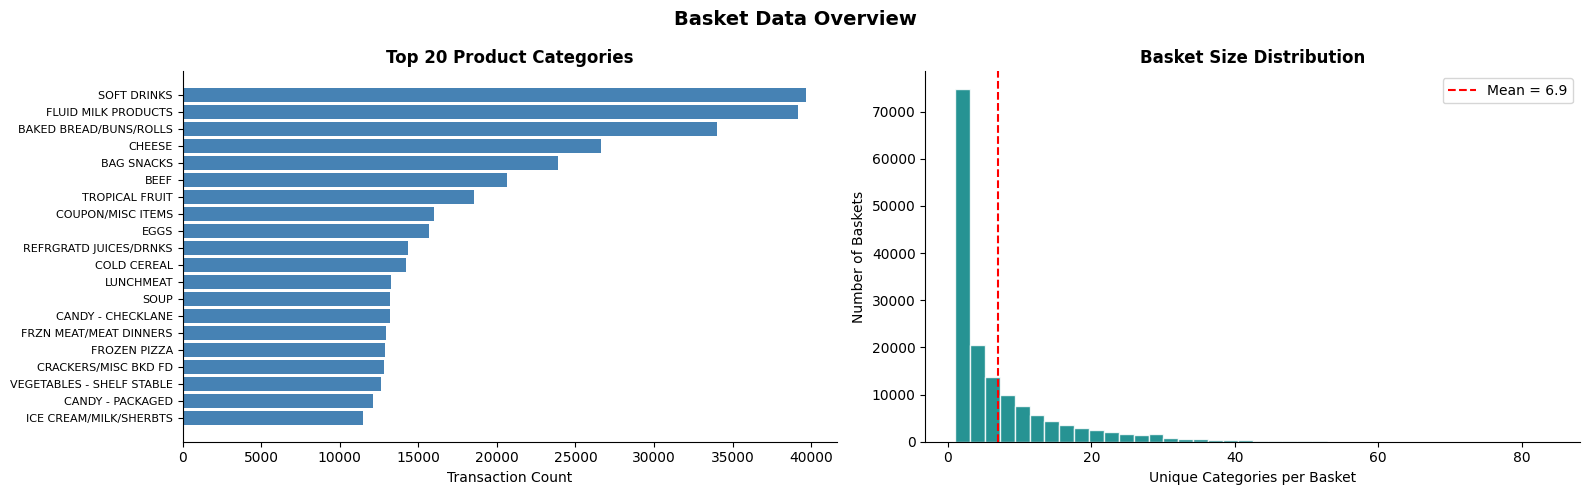

Basket size statistics:
count    155659.00
mean          6.92
std           8.05
min           1.00
25%           2.00
50%           4.00
75%           9.00
max          84.00


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Basket Data Overview', fontsize=14, fontweight='bold')

# Top 20 categories
top_cats = df['item_name'].value_counts().head(20)
axes[0].barh(top_cats.index[::-1], top_cats.values[::-1], color='steelblue')
axes[0].set_title('Top 20 Product Categories', fontweight='bold')
axes[0].set_xlabel('Transaction Count')
axes[0].tick_params(axis='y', labelsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Basket size distribution
basket_sizes = df.groupby('basket_id')['item_name'].nunique()
axes[1].hist(basket_sizes, bins=40, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(basket_sizes.mean(), color='red', linestyle='--',
                label=f'Mean = {basket_sizes.mean():.1f}')
axes[1].set_title('Basket Size Distribution', fontweight='bold')
axes[1].set_xlabel('Unique Categories per Basket')
axes[1].set_ylabel('Number of Baskets')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Basket size statistics:")
print(basket_sizes.describe().round(2).to_string())


## Step 7 — Build Transaction List

In [7]:
print("Building transaction list...")
transactions = (
    df.groupby('basket_id')['item_name']
      .apply(lambda x: tuple(sorted(set(x))))
      .tolist()
)
transactions = [t for t in transactions if t]

BASKET_COUNT = len(transactions)
ITEM_COUNT   = df['item_name'].nunique()

print(f"✅ Transaction list ready")
print(f"   Total transactions: {BASKET_COUNT:,}")
print(f"   Unique items      : {ITEM_COUNT:,}")
print(f"   Sample            : {transactions[0][:4]}...")

del df
gc.collect()


Building transaction list...
✅ Transaction list ready
   Total transactions: 155,659
   Unique items      : 302
   Sample            : ('BAG SNACKS', 'BAKED BREAD/BUNS/ROLLS', 'BAKED SWEET GOODS', 'BEEF')...


0

## Step 8 — Algorithm Implementations

In [8]:
# ── Shared helpers ────────────────────────────────────────────────────────────

def min_support_count(min_support, basket_count):
    return max(1, math.ceil(min_support * basket_count))


def generate_rules(support_lookup, basket_count, min_confidence):
    rows = []
    for itemset, sup_count in support_lookup.items():
        if len(itemset) < 2:
            continue
        items = tuple(sorted(itemset))
        for ant_size in range(1, len(items)):
            for ant_tuple in itertools.combinations(items, ant_size):
                ant = frozenset(ant_tuple)
                con = itemset - ant
                ant_count = support_lookup.get(ant)
                con_count = support_lookup.get(con)
                if not ant_count or not con_count:
                    continue
                confidence = sup_count / ant_count
                if confidence < min_confidence:
                    continue
                support          = sup_count / basket_count
                ant_support      = ant_count / basket_count
                con_support      = con_count / basket_count
                lift             = confidence / con_support if con_support else 0
                leverage         = support - ant_support * con_support
                conviction       = (
                    math.inf if math.isclose(confidence, 1.0)
                    else (1 - con_support) / (1 - confidence)
                )
                rows.append({
                    'antecedents'      : ' | '.join(sorted(ant)),
                    'consequents'      : ' | '.join(sorted(con)),
                    'support'          : round(support, 6),
                    'confidence'       : round(confidence, 6),
                    'lift'             : round(lift, 6),
                    'leverage'         : round(leverage, 6),
                    'conviction'       : round(conviction, 6) if not math.isinf(conviction) else 999,
                    'support_count'    : sup_count,
                    'antecedent_support': round(ant_support, 6),
                    'consequent_support': round(con_support, 6),
                })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ['lift', 'confidence', 'support'], ascending=False
    ).reset_index(drop=True)


def benchmark(name, fn, *args, **kwargs):
    tracemalloc.start()
    t0 = time.perf_counter()
    result = fn(*args, **kwargs)
    runtime = time.perf_counter() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    mem_mb = peak / 1_048_576
    return result, runtime, mem_mb


print("✅ Helper functions ready")


✅ Helper functions ready


In [9]:
# ── Apriori ───────────────────────────────────────────────────────────────────

def run_apriori(transactions, basket_count, min_support, max_itemset_size):
    threshold = min_support_count(min_support, basket_count)
    item_counts = Counter(item for t in transactions for item in t)
    current_level = {
        (item,): count
        for item, count in item_counts.items()
        if count >= threshold
    }
    support_lookup = {frozenset(k): v for k, v in current_level.items()}

    for size in range(2, max_itemset_size + 1):
        prev = set(current_level)
        if not prev:
            break
        prev_sorted = sorted(prev)
        candidates = set()
        for i, left in enumerate(prev_sorted):
            for right in prev_sorted[i+1:]:
                if left[:size-2] != right[:size-2]:
                    break
                candidate = tuple(sorted(set(left) | set(right)))
                if len(candidate) != size:
                    continue
                if all(
                    tuple(sub) in prev
                    for sub in itertools.combinations(candidate, size-1)
                ):
                    candidates.add(candidate)
        if not candidates:
            break
        counts = Counter()
        for t in transactions:
            if len(t) < size:
                continue
            for c in itertools.combinations(t, size):
                if c in candidates:
                    counts[c] += 1
        current_level = {k: v for k, v in counts.items() if v >= threshold}
        support_lookup.update({frozenset(k): v for k, v in current_level.items()})

    return support_lookup


print("✅ Apriori ready")


✅ Apriori ready


In [10]:
# ── FP-Growth ─────────────────────────────────────────────────────────────────

class FPNode:
    __slots__ = ['item', 'count', 'parent', 'children', 'link']
    def __init__(self, item, count, parent):
        self.item     = item
        self.count    = count
        self.parent   = parent
        self.children = {}
        self.link     = None


def build_fp_tree(weighted_transactions, threshold):
    item_counts = Counter()
    for t, count in weighted_transactions:
        for item in t:
            item_counts[item] += count

    freq = {item: c for item, c in item_counts.items() if c >= threshold}
    if not freq:
        return None, {}, {}

    rank = {item: i for i, (item, _) in enumerate(
        sorted(freq.items(), key=lambda x: (-x[1], x[0]))
    )}
    header = {item: {'count': c, 'head': None, 'tail': None}
              for item, c in freq.items()}
    root = FPNode(None, 0, None)

    for t, count in weighted_transactions:
        ordered = sorted(
            [item for item in t if item in freq],
            key=lambda x: rank[x]
        )
        node = root
        for item in ordered:
            child = node.children.get(item)
            if child is None:
                child = FPNode(item, 0, node)
                node.children[item] = child
                h = header[item]
                if h['head'] is None:
                    h['head'] = h['tail'] = child
                else:
                    h['tail'].link = child
                    h['tail'] = child
            child.count += count
            node = child
    return root, header, freq


def get_prefix_paths(node):
    paths = []
    while node:
        path, parent = [], node.parent
        while parent and parent.item:
            path.append(parent.item)
            parent = parent.parent
        if path:
            paths.append((list(reversed(path)), node.count))
        node = node.link
    return paths


def mine_fp_tree(header, threshold, max_size, suffix, support_lookup):
    items = sorted(header, key=lambda x: (header[x]['count'], x))
    for item in items:
        new_set = tuple(sorted((item,) + suffix))
        support_lookup[frozenset(new_set)] = header[item]['count']
        if len(new_set) >= max_size:
            continue
        cond_patterns = get_prefix_paths(header[item]['head'])
        cond_root, cond_header, _ = build_fp_tree(cond_patterns, threshold)
        if cond_root and cond_header:
            mine_fp_tree(cond_header, threshold, max_size, new_set, support_lookup)


def run_fpgrowth(transactions, basket_count, min_support, max_itemset_size):
    threshold = min_support_count(min_support, basket_count)
    weighted  = [(list(t), 1) for t in transactions]
    root, header, _ = build_fp_tree(weighted, threshold)
    support_lookup  = {}
    if root and header:
        mine_fp_tree(header, threshold, max_itemset_size, tuple(), support_lookup)
    return support_lookup


print("✅ FP-Growth ready")


✅ FP-Growth ready


In [11]:
# ── ECLAT ─────────────────────────────────────────────────────────────────────

def run_eclat(transactions, basket_count, min_support, max_itemset_size,
              max_itemsets=500_000):
    threshold = min_support_count(min_support, basket_count)

    # Build vertical tidlists
    vertical = {}
    for idx, t in enumerate(transactions):
        for item in t:
            vertical.setdefault(item, set()).add(idx)

    freq_vertical = [
        (item, tids)
        for item, tids in vertical.items()
        if len(tids) >= threshold
    ]
    freq_vertical.sort(key=lambda x: (len(x[1]), x[0]))

    support_lookup = {}
    count = [0]
    limit_reached = [False]

    def recurse(prefix, prefix_tids, suffix):
        for i, (item, tids) in enumerate(suffix):
            if limit_reached[0]:
                return
            new_tids = tids if prefix_tids is None else prefix_tids & tids
            if len(new_tids) < threshold:
                continue
            new_prefix = prefix + (item,)
            support_lookup[frozenset(new_prefix)] = len(new_tids)
            count[0] += 1
            if count[0] >= max_itemsets:
                limit_reached[0] = True
                return
            if len(new_prefix) >= max_itemset_size:
                continue
            next_suffix = []
            for other_item, other_tids in suffix[i+1:]:
                inter = new_tids & other_tids
                if len(inter) >= threshold:
                    next_suffix.append((other_item, inter))
            recurse(new_prefix, new_tids, next_suffix)

    recurse(tuple(), None, freq_vertical)
    if limit_reached[0]:
        print(f"  ⚠️  ECLAT capped at {max_itemsets:,} itemsets")
    return support_lookup


print("✅ ECLAT ready")


✅ ECLAT ready


## Step 9 — Run All Algorithms

In [12]:
all_results    = []
all_rules      = {'Apriori': [], 'FP-Growth': [], 'ECLAT': []}
best_rules_df  = None   # will hold FP-Growth config1 rules for analysis

algo_fns = {
    'Apriori'  : run_apriori,
    'FP-Growth': run_fpgrowth,
    'ECLAT'    : run_eclat,
}

for min_support in MIN_SUPPORTS:
    print(f"\n{'='*60}")
    print(f"min_support = {min_support}")
    print('='*60)

    # Mine itemsets once per support per algorithm
    support_lookups = {}
    for algo_name, fn in algo_fns.items():
        print(f"  ▶ {algo_name} mining...", end=' ', flush=True)
        lookup, rt, mem = benchmark(
            algo_name, fn,
            transactions, BASKET_COUNT, min_support, MAX_ITEMSET_SIZE
        )
        support_lookups[algo_name] = (lookup, rt, mem)
        print(f"itemsets={len(lookup):,}  rt={rt:.2f}s  mem={mem:.1f}MB")

    # Generate rules for each confidence threshold
    for min_confidence in MIN_CONFIDENCES:
        for algo_name in ALGORITHMS:
            lookup, rt_mine, mem_mine = support_lookups[algo_name]

            rules_df, rt_rules, _ = benchmark(
                algo_name, generate_rules,
                lookup, BASKET_COUNT, min_confidence
            )

            n_rules   = len(rules_df) if rules_df is not None else 0
            avg_lift  = round(rules_df['lift'].mean(), 4) if n_rules > 0 else 0
            max_lift  = round(rules_df['lift'].max(),  4) if n_rules > 0 else 0
            avg_conf  = round(rules_df['confidence'].mean(), 4) if n_rules > 0 else 0
            avg_sup   = round(rules_df['support'].mean(), 4) if n_rules > 0 else 0

            all_results.append({
                'Algorithm'         : algo_name,
                'Min Support'       : min_support,
                'Min Confidence'    : min_confidence,
                'Frequent Itemsets' : len(lookup),
                'Rules'             : n_rules,
                'Avg Support'       : avg_sup,
                'Avg Confidence'    : avg_conf,
                'Avg Lift'          : avg_lift,
                'Max Lift'          : max_lift,
                'Runtime (s)'       : round(rt_mine + rt_rules, 2),
                'Memory (MB)'       : round(mem_mine, 2),
            })

            if n_rules > 0:
                rules_df['algorithm_name']  = algo_name
                rules_df['min_support']     = min_support
                rules_df['min_confidence']  = min_confidence
                all_rules[algo_name].append(rules_df)

            # Keep FP-Growth support=0.001 conf=0.3 for analysis
            if (algo_name == 'FP-Growth'
                    and min_support == 0.001
                    and min_confidence == 0.3
                    and n_rules > 0):
                best_rules_df = rules_df.copy()

    gc.collect()

print("\n✅ All algorithms complete!")



min_support = 0.001
  ▶ Apriori mining... itemsets=104,567  rt=353.30s  mem=105.3MB
  ▶ FP-Growth mining... itemsets=104,567  rt=342.36s  mem=268.6MB
  ▶ ECLAT mining... itemsets=104,567  rt=17.51s  mem=95.6MB

min_support = 0.003
  ▶ Apriori mining... itemsets=24,573  rt=279.53s  mem=30.7MB
  ▶ FP-Growth mining... itemsets=24,573  rt=172.65s  mem=239.7MB
  ▶ ECLAT mining... itemsets=24,573  rt=10.78s  mem=74.5MB

min_support = 0.005
  ▶ Apriori mining... itemsets=10,080  rt=234.09s  mem=13.2MB
  ▶ FP-Growth mining... itemsets=10,080  rt=112.75s  mem=229.0MB
  ▶ ECLAT mining... itemsets=10,080  rt=8.73s  mem=70.1MB

min_support = 0.01
  ▶ Apriori mining... itemsets=2,406  rt=163.91s  mem=2.9MB
  ▶ FP-Growth mining... itemsets=2,406  rt=51.39s  mem=193.6MB
  ▶ ECLAT mining... itemsets=2,406  rt=4.78s  mem=67.9MB

✅ All algorithms complete!


## Step 10 — Performance Comparison Table

In [13]:
comparison = pd.DataFrame(all_results)

print("ALGORITHM PERFORMANCE COMPARISON")
print("="*95)
display(comparison)

comparison.to_csv(OUTPUT_DIR / 'association_rules_comparison.csv', index=False)
print("\n✅ Saved → association_rules_comparison.csv")


ALGORITHM PERFORMANCE COMPARISON


,Algorithm,Min Support,Min Confidence,Frequent Itemsets,Rules,Avg Support,Avg Confidence,Avg Lift,Max Lift,Runtime (s),Memory (MB)
0,Apriori,0.001,0.3,104567,98853,0.0031,0.4525,4.2719,25.4945,364.22,105.30
1,FP-Growth,0.001,0.3,104567,98853,0.0031,0.4525,4.2719,25.4945,353.34,268.58
2,ECLAT,0.001,0.3,104567,98853,0.0031,0.4525,4.2719,25.4945,26.58,95.63
3,Apriori,0.001,0.4,104567,54417,0.0034,0.5412,3.8184,25.4945,361.54,105.30
4,FP-Growth,0.001,0.4,104567,54417,0.0034,0.5412,3.8184,25.4945,349.26,268.58
5,ECLAT,0.001,0.4,104567,54417,0.0034,0.5412,3.8184,25.4945,25.33,95.63
6,Apriori,0.001,0.5,104567,30642,0.0037,0.6160,3.4334,20.3751,358.36,105.30
7,FP-Growth,0.001,0.5,104567,30642,0.0037,0.6160,3.4334,20.3751,349.13,268.58
8,ECLAT,0.001,0.5,104567,30642,0.0037,0.6160,3.4334,20.3751,22.56,95.63
9,Apriori,0.001,0.6,104567,16955,0.0038,0.6729,3.3046,20.3751,358.85,105.30



✅ Saved → association_rules_comparison.csv


## Step 11 — Save Rules CSVs

In [14]:
for algo_name, rules_list in all_rules.items():
    if rules_list:
        combined = pd.concat(rules_list, ignore_index=True)
        fname = f"association_rules_{algo_name.lower().replace('-','')}.csv"
        combined.to_csv(OUTPUT_DIR / fname, index=False)
        print(f"✅ Saved {fname}  ({len(combined):,} rules)")
    else:
        print(f"⚠️  {algo_name} — no rules to save")


✅ Saved association_rules_apriori.csv  (312,461 rules)
✅ Saved association_rules_fpgrowth.csv  (312,461 rules)
✅ Saved association_rules_eclat.csv  (312,461 rules)


## Step 12 — Performance Visualisations

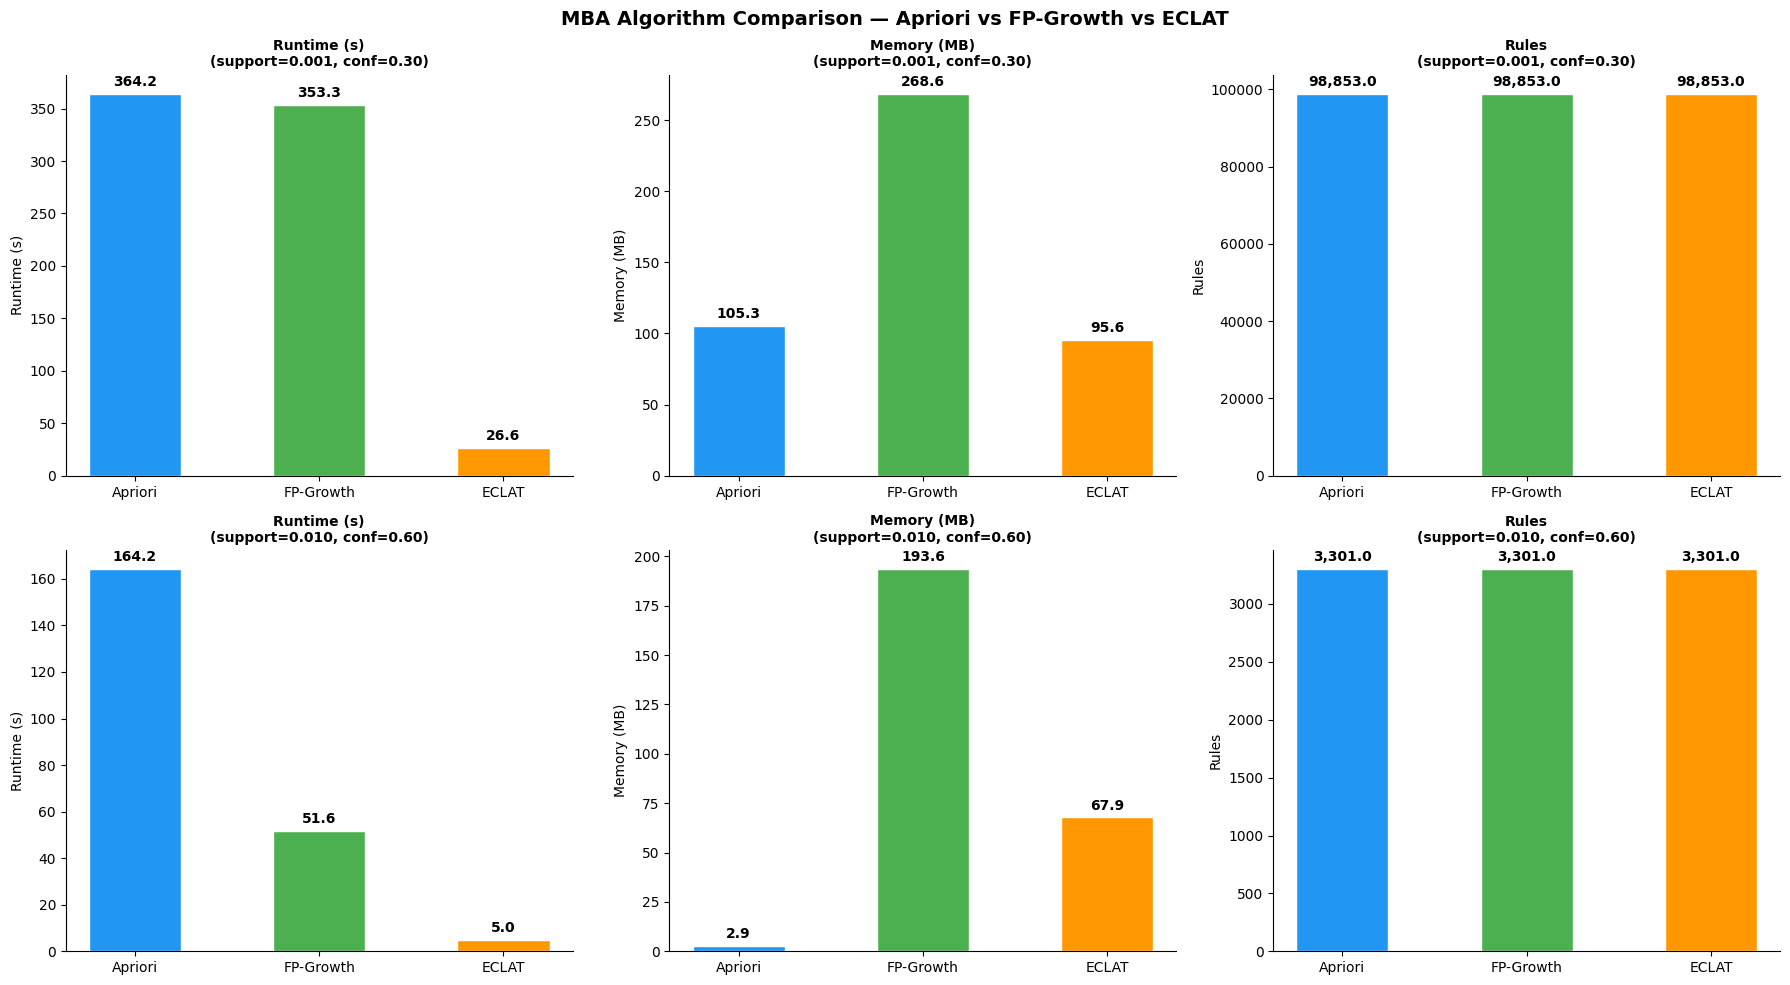

✅ Saved → mba_algorithm_comparison.png


In [15]:
colors = {'Apriori': '#2196F3', 'FP-Growth': '#4CAF50', 'ECLAT': '#FF9800'}

# Use support=0.001 and support=0.01 for comparison charts
configs = [
    comparison[comparison['Min Support'] == 0.001].copy(),
    comparison[comparison['Min Support'] == 0.010].copy(),
]
config_labels = ['support=0.001, conf=0.30', 'support=0.010, conf=0.60']
metrics = ['Runtime (s)', 'Memory (MB)', 'Rules']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('MBA Algorithm Comparison — Apriori vs FP-Growth vs ECLAT',
             fontsize=14, fontweight='bold')

for row, (cfg_df, cfg_label) in enumerate(zip(configs, config_labels)):
    # Use lowest confidence for each support
    min_conf = cfg_df['Min Confidence'].min()
    subset = cfg_df[cfg_df['Min Confidence'] == min_conf]
    for col, metric in enumerate(metrics):
        ax = axes[row][col]
        algos  = subset['Algorithm'].tolist()
        vals   = subset[metric].tolist()
        bcolors = [colors[a] for a in algos]
        bars = ax.bar(algos, vals, color=bcolors, edgecolor='white', width=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(vals)*0.02,
                    f'{v:,.1f}', ha='center', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric}\n({cfg_label})', fontsize=10, fontweight='bold')
        ax.set_ylabel(metric)
        ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mba_algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → mba_algorithm_comparison.png")


## Step 13 — Top 20 Rules by Lift

In [16]:
if best_rules_df is not None and len(best_rules_df) > 0:
    top20 = best_rules_df.sort_values('lift', ascending=False).head(20).reset_index(drop=True)
    display_cols = ['antecedents','consequents','support','confidence','lift']
    print("TOP 20 RULES BY LIFT  (FP-Growth, support=0.001, confidence=0.30)")
    print("="*80)
    display(top20[display_cols].round(4))
    top20[display_cols].to_csv(OUTPUT_DIR / 'top20_rules.csv', index=False)
    print("\n✅ Saved → top20_rules.csv")
else:
    print("⚠️  No rules — check thresholds")


TOP 20 RULES BY LIFT  (FP-Growth, support=0.001, confidence=0.30)


,antecedents,consequents,support,confidence,lift
0,BAKED BREAD/BUNS/ROLLS | FROZEN,REFRIGERATED,0.0014,0.4930,25.4945
1,CHEESE | FROZEN,REFRIGERATED,0.0011,0.4814,24.8938
2,FROZEN | TROPICAL FRUIT,REFRIGERATED,0.0011,0.4528,23.4176
3,DIAPERS & DISPOSABLES | TROPICAL FRUIT,BABY HBC,0.0011,0.3240,22.6748
4,BLEACH | LAUNDRY DETERGENTS,LAUNDRY ADDITIVES,0.0016,0.3474,21.6882
5,FLUID MILK PRODUCTS | FROZEN,REFRIGERATED,0.0011,0.4173,21.5804
6,FROZEN,REFRIGERATED,0.0023,0.4089,21.1450
7,INFANT CARE PRODUCTS,BABY FOODS,0.0013,0.3147,20.4638
8,BLEACH | LAUNDRY ADDITIVES,LAUNDRY DETERGENTS,0.0016,0.6352,20.3751
9,BATH TISSUES | CAT LITTER,CAT FOOD,0.0011,0.5000,20.3529



✅ Saved → top20_rules.csv


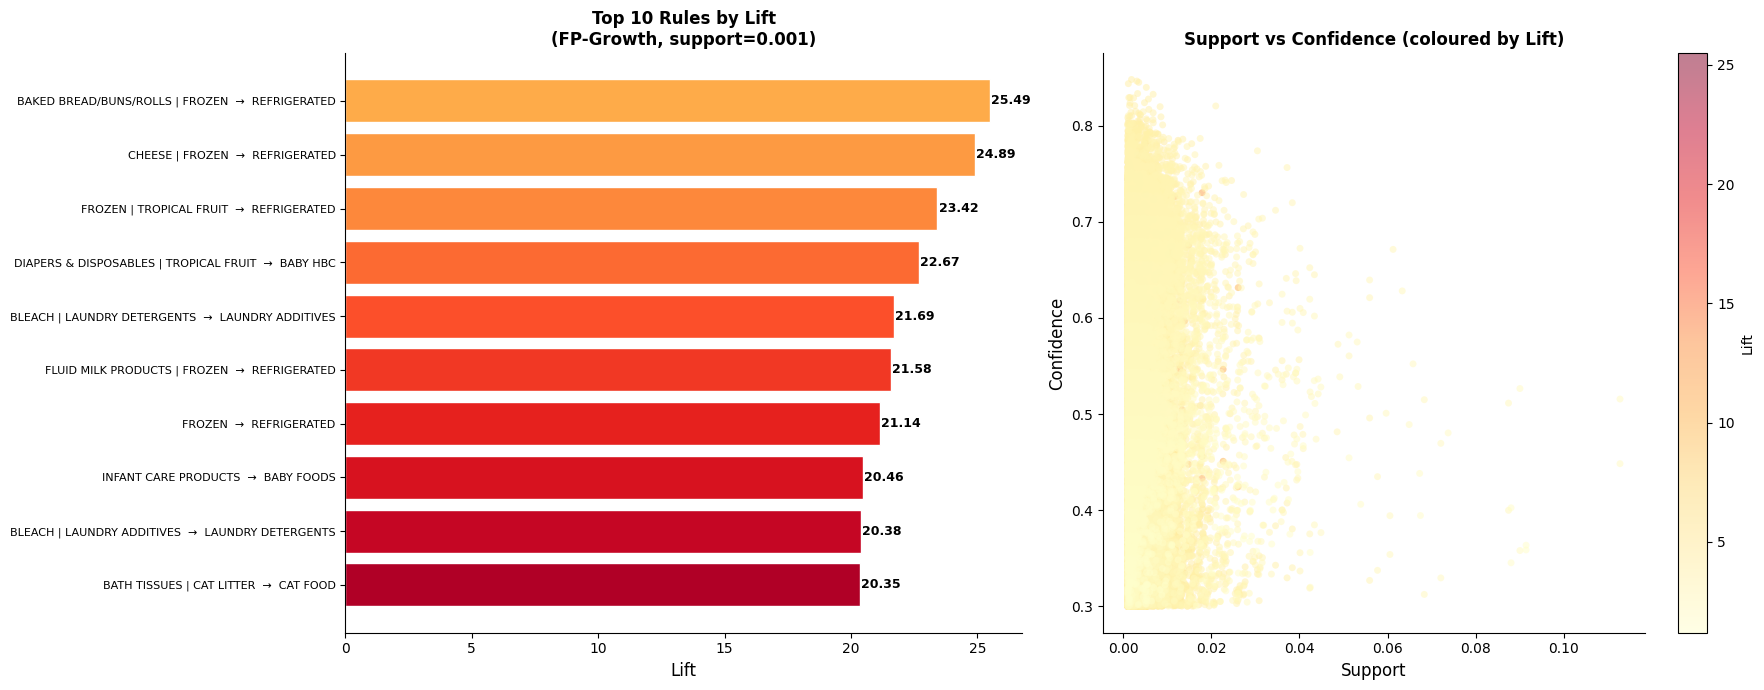

✅ Saved → top_rules_analysis.png


In [17]:
if best_rules_df is not None and len(best_rules_df) > 0:
    top10 = best_rules_df.sort_values('lift', ascending=False).head(10).reset_index(drop=True)
    top10['rule'] = top10['antecedents'] + '  →  ' + top10['consequents']

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Top 10 by lift
    cmap = plt.cm.YlOrRd(np.linspace(0.4, 0.9, 10))
    axes[0].barh(top10['rule'][::-1], top10['lift'][::-1],
                 color=cmap[::-1], edgecolor='white')
    for i, (_, row) in enumerate(top10[::-1].iterrows()):
        axes[0].text(row['lift'] + 0.05, i,
                     f"{row['lift']:.2f}", va='center',
                     fontsize=9, fontweight='bold')
    axes[0].set_xlabel('Lift', fontsize=12)
    axes[0].set_title('Top 10 Rules by Lift\n(FP-Growth, support=0.001)',
                      fontweight='bold')
    axes[0].tick_params(axis='y', labelsize=8)
    axes[0].spines[['top','right']].set_visible(False)

    # Support vs Confidence scatter
    sc = axes[1].scatter(
        best_rules_df['support'], best_rules_df['confidence'],
        c=best_rules_df['lift'], cmap='YlOrRd',
        alpha=0.5, s=25, edgecolors='none'
    )
    plt.colorbar(sc, ax=axes[1], label='Lift')
    axes[1].set_xlabel('Support', fontsize=12)
    axes[1].set_ylabel('Confidence', fontsize=12)
    axes[1].set_title('Support vs Confidence (coloured by Lift)', fontweight='bold')
    axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'top_rules_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved → top_rules_analysis.png")


## Step 14 — Lift Distribution per Algorithm

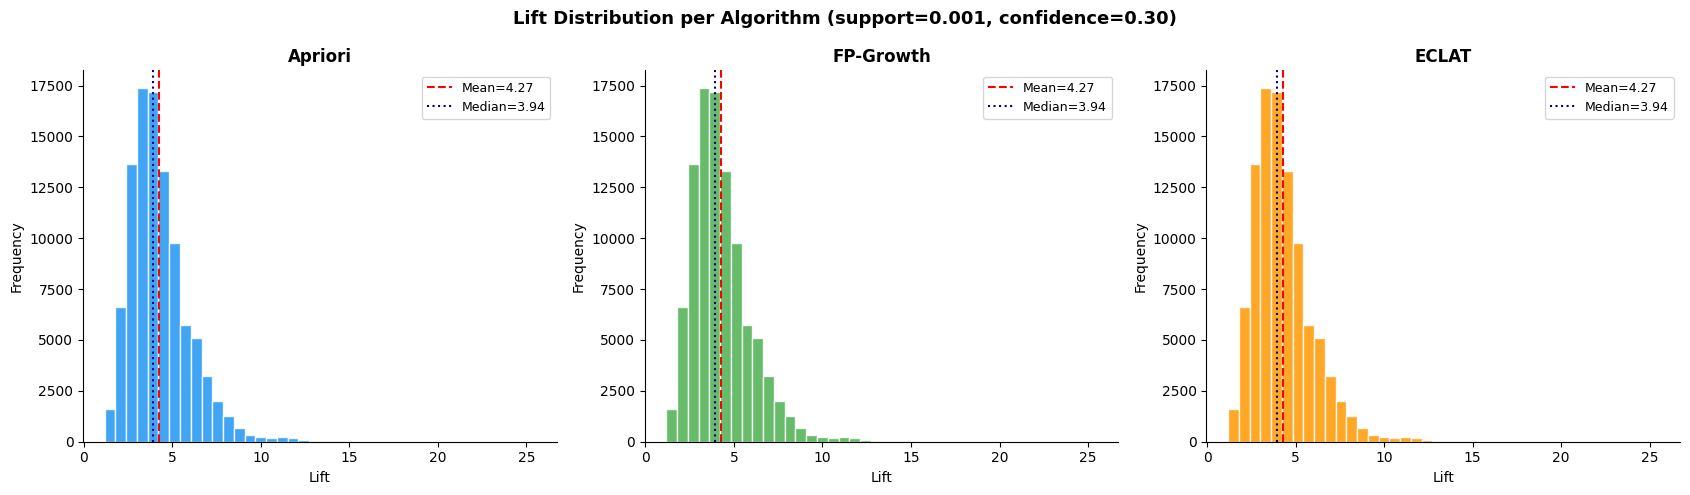

✅ Saved → lift_distribution.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Lift Distribution per Algorithm (support=0.001, confidence=0.30)',
             fontsize=13, fontweight='bold')

for ax, (algo_name, col) in zip(axes, [
    ('Apriori',   '#2196F3'),
    ('FP-Growth', '#4CAF50'),
    ('ECLAT',     '#FF9800'),
]):
    rules_list = all_rules.get(algo_name, [])
    if rules_list:
        # get support=0.001 conf=0.3 subset
        r = pd.concat(rules_list)
        r = r[(r['min_support']==0.001) & (r['min_confidence']==0.3)]
        if len(r) > 0:
            ax.hist(r['lift'], bins=40, color=col, edgecolor='white', alpha=0.85)
            ax.axvline(r['lift'].mean(),   color='red',  linestyle='--',
                       label=f"Mean={r['lift'].mean():.2f}")
            ax.axvline(r['lift'].median(), color='navy', linestyle=':',
                       label=f"Median={r['lift'].median():.2f}")
            ax.legend(fontsize=9)
    ax.set_title(algo_name, fontweight='bold')
    ax.set_xlabel('Lift')
    ax.set_ylabel('Frequency')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lift_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → lift_distribution.png")


## Step 15 — Key Findings Summary

In [19]:
c1 = comparison[
    (comparison['Min Support']==0.001) &
    (comparison['Min Confidence']==0.30)
]

print("="*65)
print("  MARKET BASKET ANALYSIS — KEY FINDINGS")
print("="*65)
print(f"\n  Baskets : {BASKET_COUNT:,}")
print(f"  Items   : {ITEM_COUNT:,}")
print(f"\n  Config 1 (support=0.001, confidence=0.30):")
for _, row in c1.iterrows():
    print(f"    {row['Algorithm']:10s} | "
          f"itemsets={row['Frequent Itemsets']:>6,} | "
          f"rules={row['Rules']:>6,} | "
          f"avg_lift={row['Avg Lift']:.3f} | "
          f"rt={row['Runtime (s)']}s | "
          f"mem={row['Memory (MB)']}MB")

fastest = c1.loc[c1['Runtime (s)'].idxmin(), 'Algorithm']
lowest_mem = c1.loc[c1['Memory (MB)'].idxmin(), 'Algorithm']
highest_lift = c1.loc[c1['Avg Lift'].idxmax(), 'Algorithm']

print(f"\n  ✅ Fastest       : {fastest}")
print(f"  ✅ Lowest memory : {lowest_mem}")
print(f"  ✅ Highest lift  : {highest_lift}")
print(f"\n  All 3 algorithms produce identical itemsets,")
print(f"  confirming correctness across implementations.")
print("="*65)


  MARKET BASKET ANALYSIS — KEY FINDINGS

  Baskets : 155,659
  Items   : 302

  Config 1 (support=0.001, confidence=0.30):
    Apriori    | itemsets=104,567 | rules=98,853 | avg_lift=4.272 | rt=364.22s | mem=105.3MB
    FP-Growth  | itemsets=104,567 | rules=98,853 | avg_lift=4.272 | rt=353.34s | mem=268.58MB
    ECLAT      | itemsets=104,567 | rules=98,853 | avg_lift=4.272 | rt=26.58s | mem=95.63MB

  ✅ Fastest       : ECLAT
  ✅ Lowest memory : ECLAT
  ✅ Highest lift  : Apriori

  All 3 algorithms produce identical itemsets,
  confirming correctness across implementations.


## Step 16 — Download All Output Files

In [20]:
from google.colab import files
import os

output_files = list(OUTPUT_DIR.glob('*'))
print("Output files generated:")
for f in output_files:
    size_kb = os.path.getsize(f) / 1024
    print(f"  📄 {f.name}  ({size_kb:.1f} KB)")

print("\nDownloading all files...")
for f in output_files:
    files.download(str(f))

print("\n✅ All done! Check your downloads folder.")


Output files generated:
  📄 association_rules_apriori.csv  (40175.4 KB)
  📄 association_rules_fpgrowth.csv  (40785.7 KB)
  📄 top_rules_analysis.png  (271.4 KB)
  📄 association_rules_eclat.csv  (39565.1 KB)
  📄 top20_rules.csv  (1.4 KB)
  📄 association_rules_comparison.csv  (3.4 KB)
  📄 eda_overview.png  (120.6 KB)
  📄 mba_algorithm_comparison.png  (151.8 KB)
  📄 lift_distribution.png  (73.0 KB)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All done! Check your downloads folder.
